# E-commerce Customer Segmentation and Prediction

## Project Overview

This project analyzes customer purchasing behavior using transaction data.

The main objectives are:
- Clean and understand the e-commerce dataset
- Analyze customer purchasing behavior
- Create RFM (Recency, Frequency, Monetary) features
- Segment customers using K-Means clustering
- Build a machine learning model to predict high-value customers
- Visualize the results and generate useful business insights

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, silhouette_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Loading the Dataset

The dataset contains e-commerce transaction records. Each row represents a transaction or product entry rather than a unique customer.

First, we will load the dataset and inspect its structure, columns, data types, and basic statistics.

In [2]:
# Load the dataset
df = pd.read_csv("data.csv", encoding="cp1252")

# Display the first 5 rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
# Check the size of the dataset
print("Dataset shape:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Check data types and missing values
print("\nDataset information:")
df.info()

Dataset shape: (541909, 8)

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


In [4]:
# Basic statistics for numerical columns
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [5]:
# Count missing values in each column
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## 3. Data Cleaning

The raw dataset contains duplicate records, missing customer IDs, and transactions with negative or zero quantities/prices.

These records can affect customer-level analysis, so they will be removed before creating the RFM features.

In [6]:
# Count duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5268


In [7]:
# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows where CustomerID is missing
df = df.dropna(subset=["CustomerID"])

In [8]:
# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [9]:
# Keep only valid purchases
df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
]

In [10]:
# Calculate the total value of each transaction row
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

print("Shape after cleaning:", df.shape)

Shape after cleaning: (392692, 9)


## 4. Exploratory Data Analysis

Exploratory Data Analysis (EDA) helps us understand the main characteristics and patterns in the cleaned dataset before applying machine learning.

We will look at:
- Total revenue
- Number of orders
- Number of customers
- Quantity and price distributions

In [11]:
print("Total Revenue:", round(df["TotalPrice"].sum(), 2))
print("Total Orders:", df["InvoiceNo"].nunique())
print("Unique Customers:", df["CustomerID"].nunique())
print("Total Products:", df["StockCode"].nunique())

Total Revenue: 8887208.89
Total Orders: 18532
Unique Customers: 4338
Total Products: 3665


In [12]:
country_revenue = (
    df.groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64

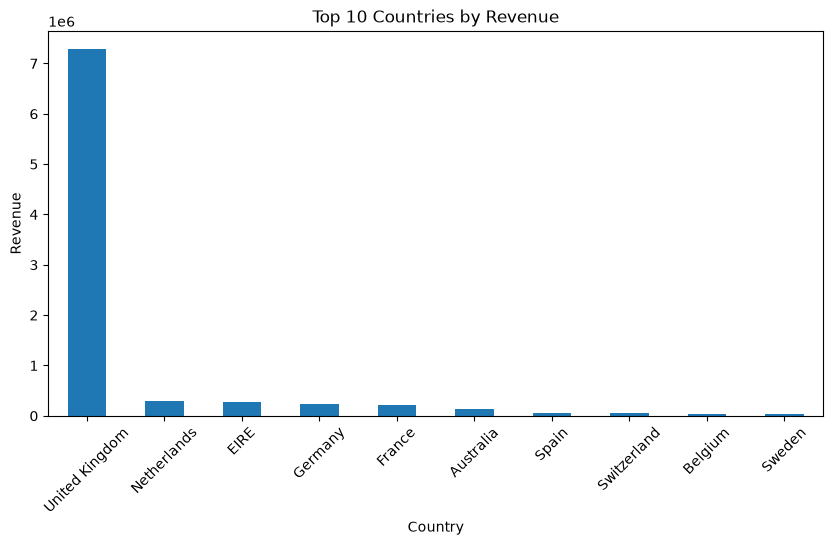

In [13]:
country_revenue.plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 Countries by Revenue"
)

plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

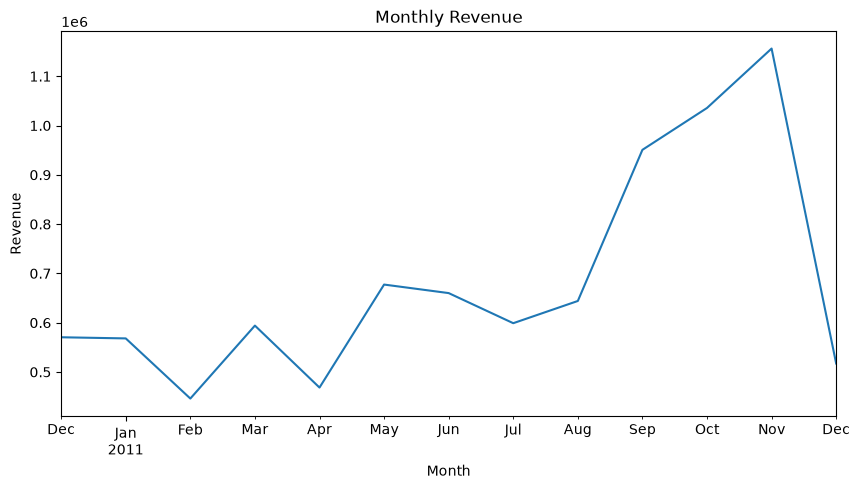

In [14]:
monthly_revenue = (
    df.set_index("InvoiceDate")
    .resample("ME")["TotalPrice"]
    .sum()
)

monthly_revenue.plot(
    figsize=(10, 5),
    title="Monthly Revenue"
)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

## 5. RFM Analysis

RFM analysis is used to understand customer purchasing behaviour.

- Recency measures how recently a customer made a purchase.
- Frequency measures how many unique orders a customer made.
- Monetary measures the total amount spent by a customer.

These three features will later be used to segment customers using K-Means clustering.

In [15]:
# Date used as the reference point for calculating Recency
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Snapshot date:", snapshot_date)

Snapshot date: 2011-12-10 12:50:00


In [16]:
rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate",
             lambda x: (snapshot_date - x.max()).days),

    Frequency=("InvoiceNo", "nunique"),

    Monetary=("TotalPrice", "sum")
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [17]:
print("Number of customers:", len(rfm))

print("\nRFM statistics:")
print(rfm[["Recency", "Frequency", "Monetary"]].describe())

Number of customers: 4338

RFM statistics:
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2048.688081
std     100.014169     7.697998    8985.230220
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     306.482500
50%      51.000000     2.000000     668.570000
75%     142.000000     5.000000    1660.597500
max     374.000000   209.000000  280206.020000


In [18]:
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
5,12352.0,36,8,2506.04
6,12353.0,204,1,89.00
7,12354.0,232,1,1079.40
8,12355.0,214,1,459.40
9,12356.0,23,3,2811.43


## 6. Log Transformation

The RFM variables have highly skewed distributions, especially Monetary values.

A log transformation is applied to reduce the effect of very large values and make the features more suitable for clustering.

In [19]:
# Apply log transformation to RFM features
rfm["Recency_Log"] = np.log1p(rfm["Recency"])
rfm["Frequency_Log"] = np.log1p(rfm["Frequency"])
rfm["Monetary_Log"] = np.log1p(rfm["Monetary"])

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Recency_Log,Frequency_Log,Monetary_Log
0,12346.0,326,1,77183.60,5.789960,0.693147,11.253955
1,12347.0,2,7,4310.00,1.098612,2.079442,8.368925
2,12348.0,75,4,1797.24,4.330733,1.609438,7.494564
3,12349.0,19,1,1757.55,2.995732,0.693147,7.472245
4,12350.0,310,1,334.40,5.739793,0.693147,5.815324


In [20]:
rfm[
    ["Recency_Log", "Frequency_Log", "Monetary_Log"]
].describe()

,Recency_Log,Frequency_Log,Monetary_Log
count,4338.000000,4338.000000,4338.000000
mean,3.830734,1.345582,6.588562
std,1.340261,0.683104,1.258438
min,0.693147,0.693147,1.558145
25%,2.944439,0.693147,5.728418
50%,3.951244,1.098612,6.506636
75%,4.962845,1.791759,7.415535
max,5.926926,5.347108,12.543284


## 7. Feature Scaling

K-Means uses distance to determine which customers are similar.

Since Recency, Frequency, and Monetary have different distributions, the log-transformed features are standardized using StandardScaler before clustering.

In [21]:
# Select the transformed RFM features
features = [
    "Recency_Log",
    "Frequency_Log",
    "Monetary_Log"
]

# Create the scaler
scaler = StandardScaler()

# Scale the RFM features
scaled_data = scaler.fit_transform(rfm[features])

# Display the first 5 scaled rows
print("Scaled RFM data:")
print(scaled_data[:5])

Scaled RFM data:
[[ 1.46199281 -0.95521426  3.7077163 ]
 [-2.03873442  1.07442519  1.41490344]
 [ 0.37310424  0.38630445  0.72002428]
 [-0.62308592 -0.95521426  0.70228691]
 [ 1.42455753 -0.95521426 -0.61451388]]


## 8. Choosing the Number of Clusters

K-Means requires the number of clusters to be specified in advance.

To choose a suitable value of K, we compare different cluster counts using:

- Inertia (Elbow Method)
- Silhouette Score

The results will help us understand the structure of the customer groups before selecting the final model.

In [24]:
inertias = []
silhouette_scores = []

for k in range(2, 9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(scaled_data)

    inertias.append(kmeans.inertia_)

    silhouette_scores.append(
        silhouette_score(scaled_data, labels)
    )

    print(
        f"K = {k} | "
        f"Inertia = {kmeans.inertia_:.2f} | "
        f"Silhouette Score = {silhouette_scores[-1]:.3f}"
    )

K = 2 | Inertia = 6483.59 | Silhouette Score = 0.433
K = 3 | Inertia = 4869.49 | Silhouette Score = 0.337
K = 4 | Inertia = 3939.05 | Silhouette Score = 0.338
K = 5 | Inertia = 3296.71 | Silhouette Score = 0.316
K = 6 | Inertia = 2855.76 | Silhouette Score = 0.312
K = 7 | Inertia = 2548.82 | Silhouette Score = 0.309
K = 8 | Inertia = 2336.34 | Silhouette Score = 0.303


## 9. Customer Segment Profiles

After applying K-Means clustering, each customer is assigned to one of four clusters.

We will compare the average Recency, Frequency, and Monetary values of each cluster to understand the purchasing behaviour of the different customer groups.|

In [26]:
# Create the final K-Means model
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Assign every customer to a cluster
rfm["Cluster"] = kmeans.fit_predict(scaled_data)

print("Clusters created successfully.")
print(rfm["Cluster"].value_counts().sort_index())

Clusters created successfully.
Cluster
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64


In [27]:
cluster_profile = rfm.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,713,12.17,13.75,8088.02
1,1622,181.51,1.32,341.00
2,837,17.70,2.19,557.32
3,1166,71.64,4.08,1801.78


In [28]:
cluster_profile.sort_values(
    "Avg_Monetary",
    ascending=False
)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,713,12.17,13.75,8088.02
3,1166,71.64,4.08,1801.78
2,837,17.70,2.19,557.32
1,1622,181.51,1.32,341.00


## 10. Customer Segment Interpretation

The cluster numbers generated by K-Means do not have an inherent business meaning.

Based on the average Recency, Frequency, and Monetary values, the clusters are given descriptive names to make the results easier to understand from a business perspective.

In [29]:
segment_names = {
    0: "Champions",
    3: "Loyal Customers",
    2: "Potential Customers",
    1: "At Risk Customers"
}

rfm["Segment"] = rfm["Cluster"].map(segment_names)

rfm[[
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary",
    "Cluster",
    "Segment"
]].head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,77183.60,3,Loyal Customers
1,12347.0,2,7,4310.00,0,Champions
2,12348.0,75,4,1797.24,3,Loyal Customers
3,12349.0,19,1,1757.55,2,Potential Customers
4,12350.0,310,1,334.40,1,At Risk Customers


## 11. Customer Segment Distribution

The following chart shows how customers are distributed across the four identified segments.

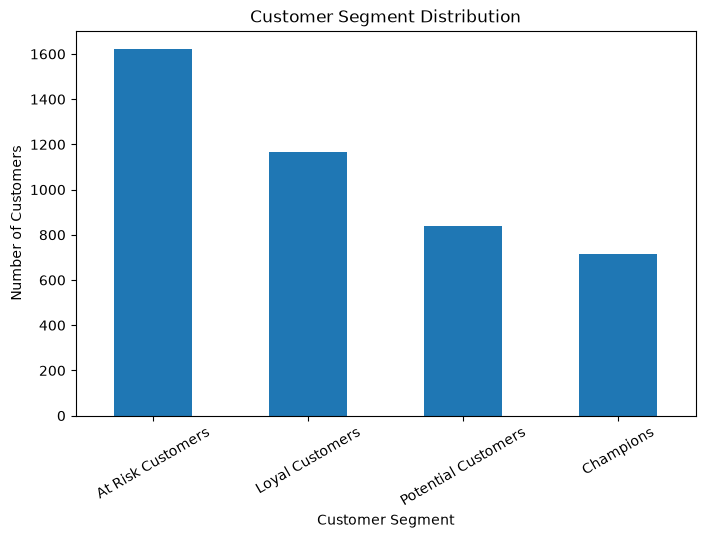

In [30]:
segment_counts = rfm["Segment"].value_counts()

segment_counts.plot(
    kind="bar",
    figsize=(8, 5),
    title="Customer Segment Distribution"
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.show()

## 10. High-Value Customer Prediction

To build a classification model, a target variable is required.

Customers whose monetary value is above the median customer spending are classified as high-value customers. The remaining customers are classified as non-high-value customers.

In [31]:
# Find the median customer spending
median_spend = rfm["Monetary"].median()

print("Median customer spending:", round(median_spend, 2))

# Create the target variable
rfm["HighValue"] = (
    rfm["Monetary"] > median_spend
).astype(int)

print("\nHigh-value customer counts:")
print(rfm["HighValue"].value_counts())

Median customer spending: 668.57

High-value customer counts:
HighValue
1    2169
0    2169
Name: count, dtype: int64


In [32]:
# Features used by the model
X = rfm[["Recency", "Frequency"]]

# Target variable
y = rfm["HighValue"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Recency  Frequency
0      326          1
1        2          7
2       75          4
3       19          1
4      310          1

Target:
0    1
1    1
2    1
3    1
4    0
Name: HighValue, dtype: int64


## 12. Train-Test Split

The customer data is divided into training and testing sets.

The training set is used to train the Random Forest model, while the testing set is used to evaluate how well the model performs on unseen customers.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training customers:", len(X_train))
print("Testing customers:", len(X_test))

Training customers: 3470
Testing customers: 868


## 13. Random Forest Classification

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to make predictions.

In this project, the Random Forest model is used to predict whether a customer is classified as high-value based on Recency and Frequency.

In [34]:
# Create the Random Forest model
clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
clf.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [35]:
# Predict HighValue for the test customers
y_pred = clf.predict(X_test)

print("Predictions created successfully.")

Predictions created successfully.


In [36]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 79.95 %


## Model Evaluation

The Random Forest model is evaluated using accuracy, precision, recall, and F1-score.

These metrics provide a more complete understanding of the classification model's performance.

In [37]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80       434
           1       0.79      0.81      0.80       434

    accuracy                           0.80       868
   macro avg       0.80      0.80      0.80       868
weighted avg       0.80      0.80      0.80       868



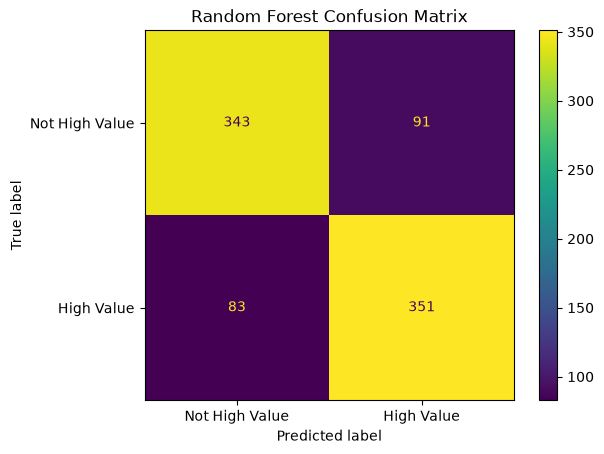

In [40]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not High Value", "High Value"]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

In [41]:
importance = pd.Series(
    clf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Feature Importance:")
print(importance)

Feature Importance:
Frequency    0.594349
Recency      0.405651
dtype: float64


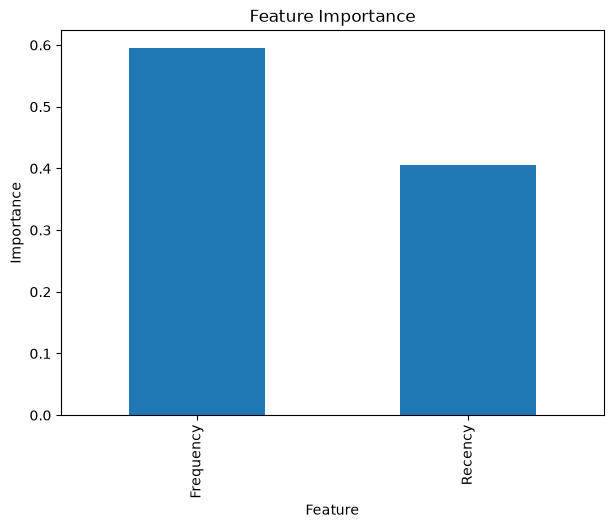

In [42]:
importance.plot(
    kind="bar",
    figsize=(7, 5),
    title="Feature Importance"
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.show()

## Saving Models and Results

The trained machine learning models and processed customer data are saved

In [43]:
# Save the K-Means model
joblib.dump(kmeans, "customer_segmentation_model.pkl")

# Save the Random Forest model
joblib.dump(clf, "customer_predictor.pkl")

# Save the scaler
joblib.dump(scaler, "rfm_scaler.pkl")

# Save customer segmentation results
rfm.to_csv("customer_segments.csv", index=False)

# Save cluster profile
cluster_profile.to_csv("segment_profile.csv")

print("All models and results saved successfully")

All models and results saved successfully


In [44]:
final_summary = rfm.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Total_Revenue=("Monetary", "sum")
).round(2)

final_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
Segment,,,,,
At Risk Customers,1622,181.51,1.32,341.00,553099.77
Champions,713,12.17,13.75,8088.02,5766757.07
Loyal Customers,1166,71.64,4.08,1801.78,2100873.02
Potential Customers,837,17.70,2.19,557.32,466479.03
